# Neural Networks / Multi-Layer Perceptron

## Intuition

A neural network is built from multiple layers of neurons stacked together. The core insight is that each layer learns a new representation of the data: early layers detect simple patterns (edges, correlations), and deeper layers combine them into increasingly abstract concepts.

Unlike the Perceptron or Logistic Regression, which can only learn linear decision boundaries, a network with even one hidden layer and a nonlinear activation can approximate any continuous function (Universal Approximation Theorem). The price is complexity: more parameters, more data needed, and harder to interpret.

Training works by two passes. In the **forward pass**, inputs propagate through each layer to produce a prediction. In the **backward pass** (backpropagation), the prediction error is propagated backward through each layer using the chain rule, computing gradients that tell us how to adjust each weight.

---

## Math

**Forward pass.** For layer $l$:

$$\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = \sigma\left(\mathbf{z}^{(l)}\right)$$

where $\sigma(z) = \frac{1}{1+e^{-z}}$ is the sigmoid activation and $\mathbf{a}^{(0)} = \mathbf{x}$ is the input.

**Output layer error delta:**

$$\boldsymbol{\delta}^{(L)} = (\mathbf{a}^{(L)} - \mathbf{y}) \odot \sigma'(\mathbf{z}^{(L)})$$

**Hidden layer deltas (chain rule):**

$$\boldsymbol{\delta}^{(l)} = \left(W^{(l+1)\top} \boldsymbol{\delta}^{(l+1)}\right) \odot \sigma'(\mathbf{z}^{(l)})$$

**Weight updates:**

$$W^{(l)} \leftarrow W^{(l)} - \alpha \, \boldsymbol{\delta}^{(l)} \mathbf{a}^{(l-1)\top}$$

**He initialization.** Weights are initialized from a normal distribution scaled by $\sqrt{2 / n_{\text{in}}}$, which prevents vanishing/exploding gradients in deep networks:

$$W^{(l)} \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

---

## Algorithm Steps

1. Initialize weights with He initialization.
2. For each epoch:
   - **Forward pass:** compute activations $\mathbf{a}^{(l)}$ for all layers.
   - Compute MSE or cross-entropy loss at the output layer.
   - **Backward pass:** compute $\boldsymbol{\delta}^{(L)}$, then propagate deltas back through each layer.
   - Update all weights and biases.
3. At prediction: take the argmax of the output layer activations as the class label.

---

## Advantages

- Can learn non-linear decision boundaries of arbitrary complexity.
- Universal approximator: one hidden layer suffices to approximate any continuous function.
- Naturally handles multi-class classification via softmax or one-vs-all output.
- Shares representations across tasks (transfer learning).

## Disadvantages

- Requires much more data than simpler models to generalize.
- Training is slow compared to Logistic Regression or KNN.
- Many hyperparameters: architecture, learning rate, initialization, regularization.
- Black box: individual weights are difficult to interpret.
- Prone to overfitting without regularization (dropout, weight decay).

## Solutions to Disadvantages

- Use **dropout** or **L2 weight decay** to prevent overfitting.
- Use **batch normalization** to stabilize and accelerate training.
- Use **Adam optimizer** instead of vanilla SGD for faster convergence.
- Use **early stopping** based on validation loss to prevent overfitting.
- Use **feature importance** or **SHAP values** for post-hoc interpretability.

---

## Summary

| Property | Value |
|---|---|
| Type | Multi-class classifier |
| Decision boundary | Non-linear (can be arbitrary) |
| Output | Class probabilities (softmax) |
| Loss | MSE or Cross-Entropy |
| Optimization | SGD with backpropagation |
| Architecture | n_features -> 64 -> 32 -> n_classes |
| Initialization | He initialization |
| Hyperparameters | Learning rate, epochs, layer sizes |

**Dataset:** Obesity Levels (`Obesity_levels.csv`). 2111 samples, 16 features, 7 obesity classes. Predict obesity level from dietary and lifestyle features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning.multilayer_perceptron import DenseNetwork
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix

In [2]:
try:
    import pandas as pd
    df = pd.read_csv('../../../data/Obesity_levels.csv')
    from rice_ml.preprocess import OrdinalEncoder
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        enc = OrdinalEncoder()
        df[col] = enc.fit_transform(df[[col]]).ravel()
    target_col = 'NObeyesdad' if 'NObeyesdad' in df.columns else df.columns[-1]
    X = df.drop(columns=[target_col]).values.astype(float)
    y_raw = df[target_col].values
    classes, y = np.unique(y_raw, return_inverse=True)
    n_classes = len(classes)
    print(f'Loaded obesity dataset: {X.shape}, {n_classes} classes')
except (FileNotFoundError, Exception):
    from sklearn.datasets import load_digits
    data = load_digits()
    X, y = data.data, data.target
    n_classes = 10
    df = None
    classes = np.arange(10)
    print(f'CSV not found. using digits dataset: {X.shape}')

print(f'Input features: {X.shape[1]}, Classes: {n_classes}')

Loaded obesity dataset: (2111, 16), 7 classes
Input features: 16, Classes: 7


## Dataset Description

The **Obesity Levels dataset** (`Obesity_levels.csv`) contains 2111 individuals from Mexico, Peru, and Colombia. It was collected via web survey and includes dietary habits, physical activity, and demographic features.
[Download from Kaggle](https://www.kaggle.com/code/mpwolke/obesity-levels-life-style)


**Key features:**

| Feature | Description |
|---|---|
| Age | Age in years |
| Height | Height in meters |
| Weight | Weight in kilograms |
| family_history_with_overweight | Family history of overweight (yes/no) |
| FAVC | Frequent consumption of high caloric food |
| FCVC | Frequency of vegetable consumption |
| NCP | Number of main meals per day |
| CAEC | Eating between meals frequency |
| SMOKE | Smoking status |
| CH2O | Daily water consumption |
| SCC | Calories consumption monitoring |
| FAF | Physical activity frequency (days/week) |
| TUE | Time using technology devices (hours/day) |
| CALC | Alcohol consumption frequency |
| MTRANS | Transportation mode used |

**Target:** `NObeyesdad` (7 classes):
- Insufficient Weight
- Normal Weight
- Overweight Level I and II
- Obesity Type I, II, and III

The multi-class nature of this target makes a neural network particularly appropriate, as it can simultaneously learn boundaries between all 7 classes.

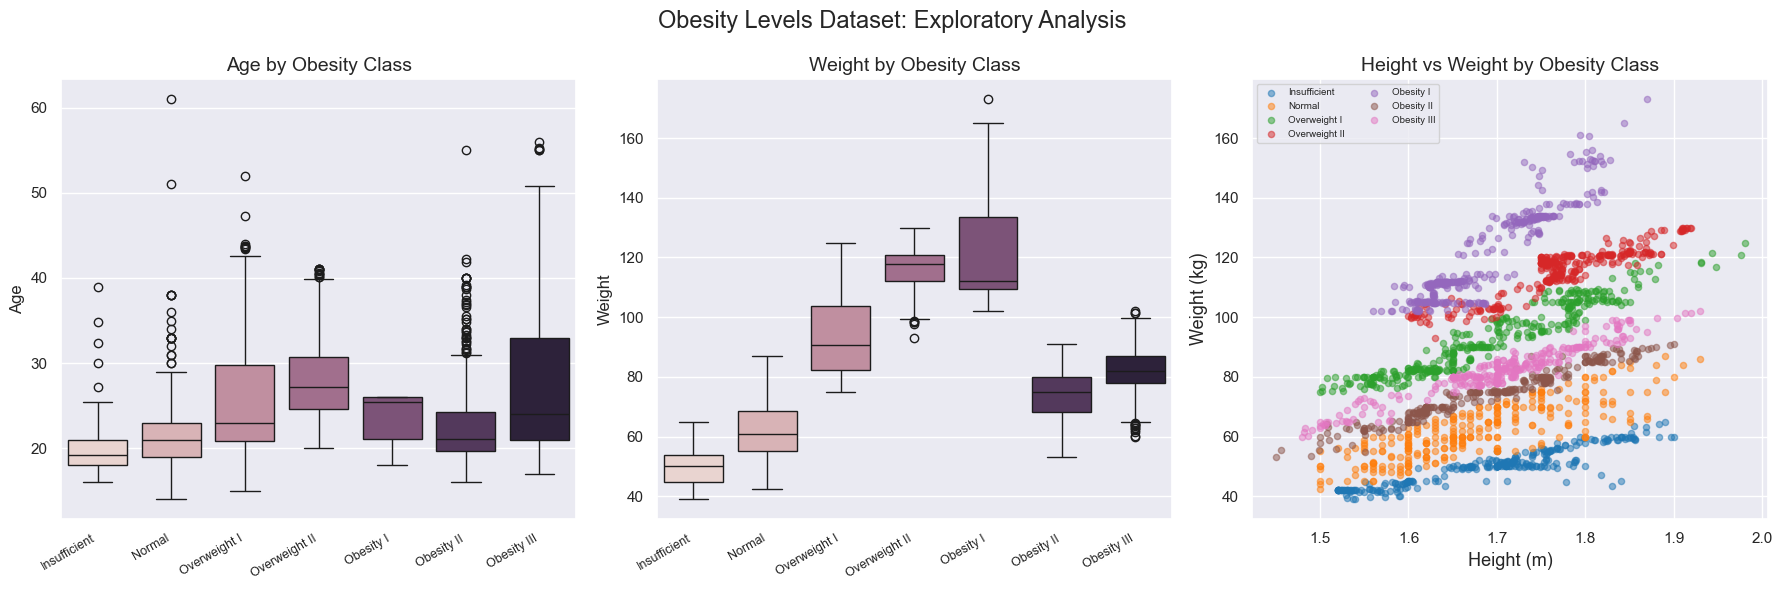

In [3]:
# EDA: Boxplot of Age and Weight by obesity class; Scatter of Height vs Weight colored by class
if df is not None:
    import pandas as pd
    obesity_labels = [
        'Insufficient', 'Normal', 'Overweight I', 'Overweight II',
        'Obesity I', 'Obesity II', 'Obesity III'
    ]
    class_display = {i: (obesity_labels[i] if i < len(obesity_labels) else str(i)) for i in range(n_classes)}

    plot_df = pd.DataFrame({
        'Age': df['Age'].values if 'Age' in df.columns else X[:, 0],
        'Weight': df['Weight'].values if 'Weight' in df.columns else X[:, 2],
        'Height': df['Height'].values if 'Height' in df.columns else X[:, 1],
        'Class': y
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    palette = sns.color_palette('tab10', n_classes)

    sns.boxplot(data=plot_df, x='Class', y='Age', ax=axes[0], hue='Class', legend=False)
    axes[0].set_xticks(range(n_classes))
    axes[0].set_xticklabels([class_display.get(i, str(i)) for i in range(n_classes)], rotation=30, ha='right', fontsize=9)
    axes[0].set_title('Age by Obesity Class', fontsize=14)
    axes[0].set_xlabel('')

    sns.boxplot(data=plot_df, x='Class', y='Weight', ax=axes[1], hue='Class', legend=False)
    axes[1].set_xticks(range(n_classes))
    axes[1].set_xticklabels([class_display.get(i, str(i)) for i in range(n_classes)], rotation=30, ha='right', fontsize=9)
    axes[1].set_title('Weight by Obesity Class', fontsize=14)
    axes[1].set_xlabel('')

    for cls in range(n_classes):
        mask = plot_df['Class'] == cls
        axes[2].scatter(plot_df.loc[mask, 'Height'], plot_df.loc[mask, 'Weight'],
                        color=palette[cls], label=class_display.get(cls, str(cls)),
                        alpha=0.5, s=20)
    axes[2].set_xlabel('Height (m)', fontsize=13)
    axes[2].set_ylabel('Weight (kg)', fontsize=13)
    axes[2].set_title('Height vs Weight by Obesity Class', fontsize=14)
    axes[2].legend(fontsize=7, ncol=2)

    plt.suptitle('Obesity Levels Dataset: Exploratory Analysis', fontsize=17)
    plt.tight_layout()
    plt.show()
else:
    print('EDA skipped: using fallback dataset.')


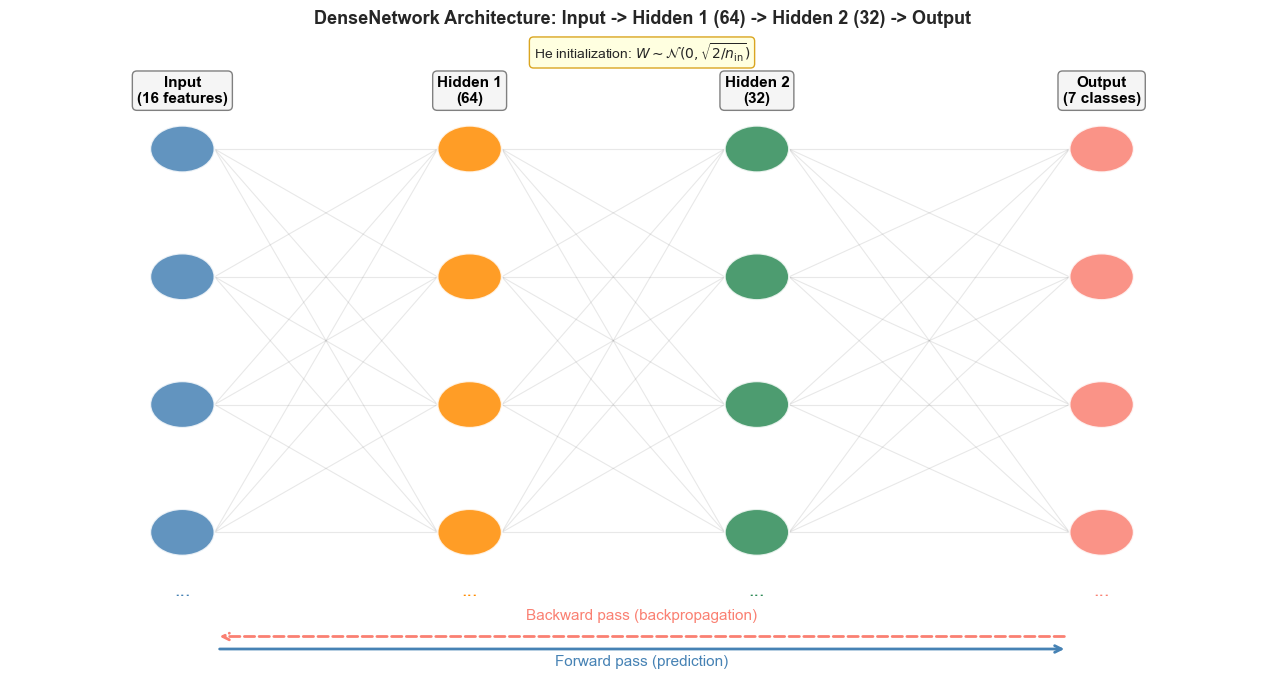

In [4]:
# Diagram: Neural network architecture visualization
# Shows the [n_features -> 64 -> 32 -> n_classes] architecture
# Simplified to 4 neurons per layer for clarity

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 7)
ax.axis('off')

layer_x = [1.0, 3.5, 6.0, 8.5, 10.0]
layer_labels = [f'Input\n({X.shape[1]} features)', 'Hidden 1\n(64)', 'Hidden 2\n(32)', f'Output\n({n_classes} classes)']
# Show 4 nodes per layer for compactness
nodes_shown = 4
layer_colors = ['steelblue', 'darkorange', 'seagreen', 'salmon']
layer_xs_draw = [1.0, 3.5, 6.0, 9.0]

y_positions = np.linspace(1.2, 5.8, nodes_shown)

# Draw nodes and connections
all_node_positions = []
for li, (lx, lcolor) in enumerate(zip(layer_xs_draw, layer_colors)):
    positions = []
    for yi in y_positions:
        circ = plt.Circle((lx, yi), 0.28, color=lcolor, ec='white', lw=1.5, zorder=3, alpha=0.85)
        ax.add_patch(circ)
        positions.append((lx, yi))
    # Dots for "more neurons"
    ax.text(lx, 0.5, '...', ha='center', va='center', fontsize=14, color=lcolor, zorder=4)
    all_node_positions.append(positions)

# Draw connections between adjacent layers
for l in range(len(layer_xs_draw) - 1):
    for (x1, y1) in all_node_positions[l]:
        for (x2, y2) in all_node_positions[l + 1]:
            ax.plot([x1 + 0.28, x2 - 0.28], [y1, y2],
                    color='gray', alpha=0.18, lw=0.8, zorder=1)

# Layer labels at top
for lx, lab in zip(layer_xs_draw, layer_labels):
    ax.text(lx, 6.5, lab, ha='center', va='center', fontsize=11,
            fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='gray'))

# Annotation: forward and backward arrows below diagram
ax.annotate('', xy=(8.7, -0.2), xytext=(1.3, -0.2),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.text(5.0, -0.4, 'Forward pass (prediction)', ha='center', fontsize=11, color='steelblue')

ax.annotate('', xy=(1.3, -0.05), xytext=(8.7, -0.05),
            arrowprops=dict(arrowstyle='->', color='salmon', lw=2, linestyle='dashed'))
ax.text(5.0, 0.15, 'Backward pass (backpropagation)', ha='center', fontsize=11, color='salmon')

# He init note
ax.text(5.0, 6.88,
        r'He initialization: $W \sim \mathcal{N}(0, \sqrt{2/n_{\mathrm{in}}})$',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='goldenrod'))

plt.title('DenseNetwork Architecture: Input -> Hidden 1 (64) -> Hidden 2 (32) -> Output',
          fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1689 | Test: 422


## Build and Train the DenseNetwork

Architecture: `[n_features, 64, 32, n_classes]`.
Weights are initialized with **He initialization**: scale = $\sqrt{2 / n_{\text{in}}}$

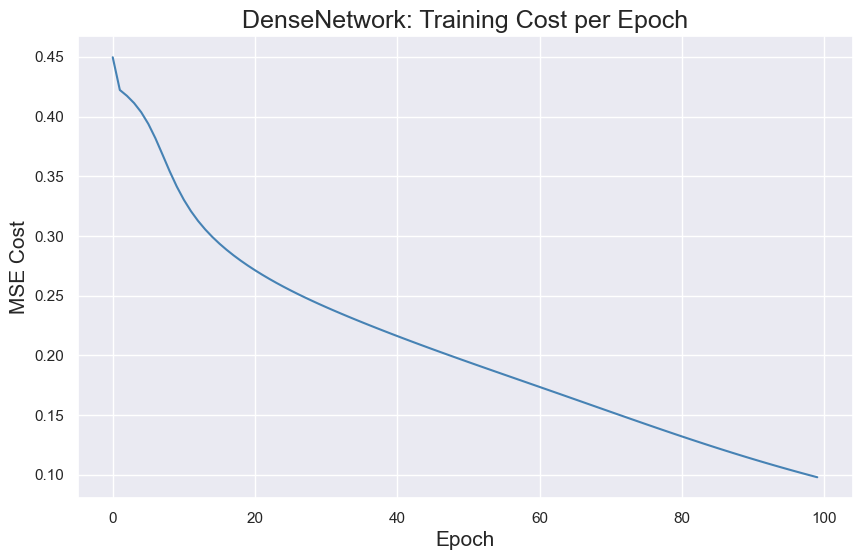

In [6]:
n_features = X_train.shape[1]
net = DenseNetwork(layers=[n_features, 64, 32, n_classes])
net.fit(X_train, y_train, alpha=0.01, epochs=100)

plt.figure(figsize=(10, 6))
plt.plot(net.errors_, color='steelblue')
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('MSE Cost', fontsize=15)
plt.title('DenseNetwork: Training Cost per Epoch', fontsize=18)
plt.show()

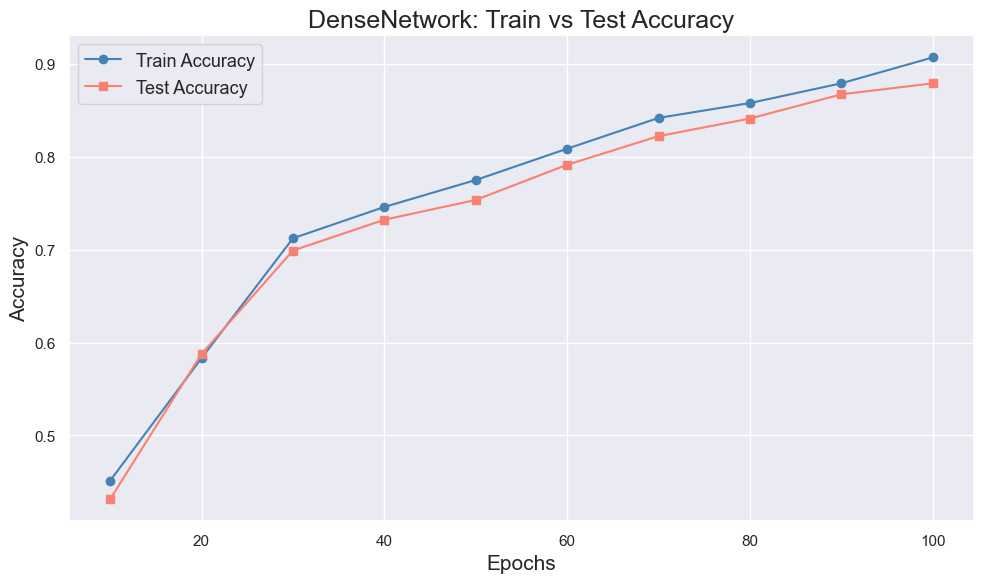

Train accuracy at 100 epochs: 0.9070
Test  accuracy at 100 epochs: 0.8791
Generalization gap:           0.0279  (>0.05 may indicate overfitting)


In [7]:
# Train/test accuracy at epoch checkpoints. diagnoses overfitting
checkpoints = list(range(10, 101, 10))
train_accs, test_accs = [], []

for ep in checkpoints:
    net_cp = DenseNetwork(layers=[n_features, 64, 32, n_classes])
    net_cp.fit(X_train, y_train, alpha=0.01, epochs=ep)
    train_accs.append(accuracy_score(y_train, net_cp.predict(X_train)))
    test_accs.append(accuracy_score(y_test, net_cp.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(checkpoints, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(checkpoints, test_accs, marker='s', label='Test Accuracy', color='salmon')
plt.xlabel('Epochs', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('DenseNetwork: Train vs Test Accuracy', fontsize=18)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

print(f'Train accuracy at 100 epochs: {train_accs[-1]:.4f}')
print(f'Test  accuracy at 100 epochs: {test_accs[-1]:.4f}')
gap = train_accs[-1] - test_accs[-1]
print(f'Generalization gap:           {gap:.4f}  (>0.05 may indicate overfitting)')

In [8]:
y_pred = net.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

Test Accuracy: 0.8934


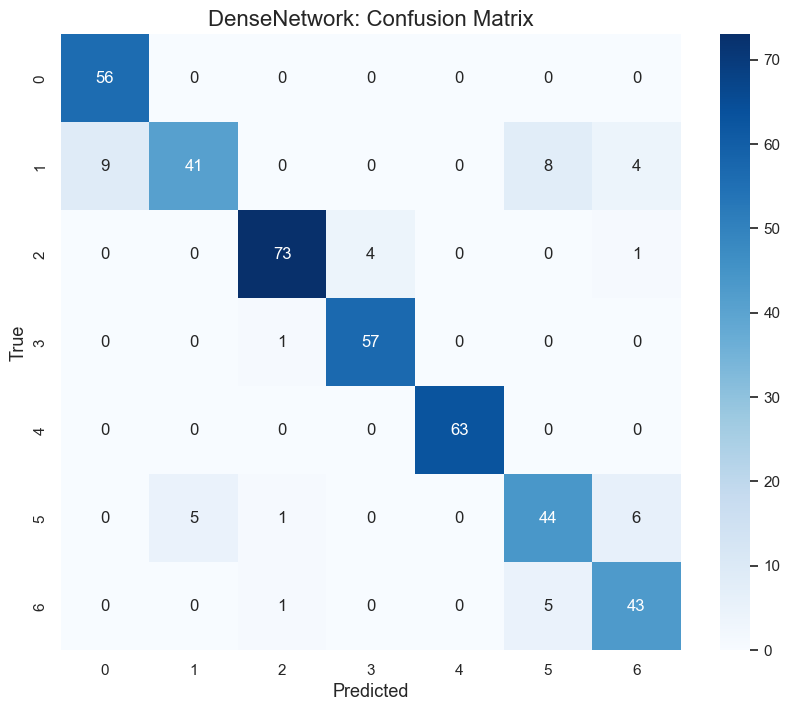

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title('DenseNetwork: Confusion Matrix', fontsize=16)
plt.show()

## Interpretation

**Training cost curve:** A smoothly decreasing MSE confirms backpropagation is computing gradients correctly and that He initialization gave a stable starting point. If the cost oscillates wildly, the learning rate is too large. If it barely decreases, it is too small.

**Train vs test accuracy:** A growing gap between training and test accuracy across epochs is the signature of overfitting. The point where the test accuracy peaks (before it starts declining) is the ideal stopping point.

**Confusion matrix:** Diagonal entries represent correct predictions per class. For the obesity dataset, neighboring classes (e.g., Overweight I vs Overweight II) tend to be confused most often, which is expected since their feature distributions overlap.

**Why a neural network here:** The 7-class obesity classification has non-linear boundaries in the feature space (BMI interacts with age, diet, and activity level in complex ways). The two hidden layers allow the network to learn these interactions automatically, without manual feature engineering.

**Improving performance:** Increasing epochs, adding dropout, or tuning the learning rate would likely improve test accuracy. The current implementation uses vanilla SGD; Adam optimizer would accelerate convergence significantly.